In [1]:
import matplotlib.pyplot as plt
import numpy as np

# **Metodo agli Elementi Finiti (stazionario) - Parte 2**

## Condizioni di Neumann

Per problemi mono-dimensionali, definiti su un certo intervallo $[a,b]\subset\mathbb{R}$, una condizione al bordo della forma</br></br>
$$u'(b)=\gamma,$$

o, in alternativa, $u'(a)=\gamma$, è detta condizione di Neumann. Nei metodi agli elementi finiti, questo tipo di condizione viene tipicamente gestita includendo esplicitamente un termine di bordo nella formulazione variazionale. Ad esempio, si consideri il seguente problema con condizioni miste Dirichlet-Neumann,

$$\begin{cases}
-u'' = f, & \text{in}\;(a,b)\\\\
u(a)=\alpha,\;\;
u'(b)=\gamma.
\end{cases}$$

Posto $V_{\text{test}}:=\{v\in H^{1}(a,b)\;|\;v(a)=0\}$, la sua formulazione debole è

$$\int_a^b-u''vdx = \int_a^b fvdx, \quad\quad \forall v\in V_{\text{test}}\quad\rightsquigarrow\quad\int_a^bu'v'dx - \left[u'v\right]\Big |^{b}_{a}= \int_a^b fvdx, \quad\quad \forall v\in V_{\text{test}}$$

$$\rightsquigarrow\int_a^bu'v'dx = \int_a^b fvdx + \left[u'v\right]\Big |^{b}_{a},\quad\quad \forall v\in V_{\text{test}}$$

$$\rightsquigarrow\int_a^bu'v'dx = \int_a^b fvdx + \gamma v(b),\quad\quad \forall v\in V_{\text{test}}.$$

Il termine $\gamma v(b)$ produce quindi una modifica in corrispondenza dell'ultimo nodo della mesh, che va gestita opportunamente.

<mark>**Esercizio 1.1**</mark></br>

Si consideri il seguente problema differenziale

$$\begin{cases}
-u''=30x, & x\in(0,1)\\
u(0)=0,\\u'(1)=3.
\end{cases}$$

Risolvere il problema implementando il metodo agli elementi finiti (grado polinomiale $r=1$, passo della mesh $h=0.1$). Confrontare graficamente la soluzione ottenuta con la soluzione esatta, $u(x)=18x-5x^3.$

In [7]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1
# bc di Neumann
gamma = 3

# generazione griglia
Nele=int((b-a)/h)
grid=Grid(a,b,Nele)
grid.compute_geometry()

# assemblaggio matrice di rigidezza
A=diffusion(grid)

# assemblaggio termine noto con condizioni di Neumann
f=lambda x: 30*x
f_dofs=fun2dof(grid, f)
M=mass(grid)
F=M @ f_dofs

# Neumann al bordo destro
F[-1]+= gamma

# gestione condizioni di Dirichlet
dirichlet_nodes = [0]
dirichlet_values = [0]

# creazione vettore dei valori al bordo, inizializzato a zero
bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values

# costruzione matrice di restrizione R
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)

# Restrizione di A e del termine noto
A_0= R @ A @ R.T
F_0= R @ (F-A@bc_values)

# risoluzione sistema lineare
u_0=np.linalg.solve (A_0, F_0)

# aggiunta condizione di Dirichlet
u=bc_values + R.T@ u_0

print(u)


[ 0.     1.795  3.56   5.265  6.88   8.375  9.72  10.885 11.84  12.555
 13.   ]


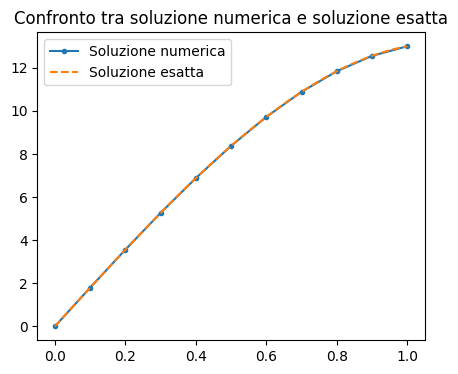

In [8]:
# rappresentazione grafica della soluzione numerica e confronto con soluzione esatta

# soluzione esatta
uex = lambda x: 18 * x - 5 * (x**3)
xplot = np.linspace(a, b, 1000)

plt.figure(figsize=(5, 4))
plt.plot(grid.nodes, u, marker=".", label="Soluzione numerica")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")

plt.title("Confronto tra soluzione numerica e soluzione esatta")
plt.legend()
plt.show()

<mark>**Esercizio 1.2**</mark></br>

Ripetere l'Es. 1.1 invertendo le condizioni di Neumann e Dirichlet, cioè risolvendo

$$\begin{cases}
-u''=30x & x\in(0,1)\\
u'(0)=3\\u(1)=0,
\end{cases}$$

la cui soluzione esatta è $u(x)=3x-5x^3+2.$

In [ ]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1
# numero elementi
Nele = int((b - a) / h)
# creazione griglia
grid=Grid(a, b, Nele)
grid.compute_geometry()

# assemblaggio matrice di rigidezza
A=diffusion(grid)

# assemblaggio termine noto con condizioni di Neumann
f= lambda x: 30*x
f_dofs=fun2dof(grid, f)
M=mass(grid)
F= M @ f_dofs

#neumann al bordo sx
F[0] += gamma

# gestione condizioni di Dirichlet
dirichlet_nodes = [Nele]
dirichlet_values = [0]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)
print(R)

A_0 = ...
rhs_0 = ...

# risoluzione sistema lineare
u_0 = ...

# aggiunta condizione di Dirichlet
u = ...

In [ ]:
# rappresentazione grafica della soluzione numerica e confronto con soluzione esatta
# soluzione esatta
uex = lambda x: 3 * x - 5 * (x**3) + 2
xplot = np.linspace(a, b, 1000)


plt.figure(figsize=(4, 3))
plt.plot(grid.nodes, u, marker=".", label="Soluzione numerica")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")

plt.title("Confronto tra soluzione numerica e soluzione esatta")
plt.legend()
plt.show()

# Equazioni di diffusione-trasporto (esempio di trasporto dominante)

Si consideri il seguente problema differenziale, descrivente un fenomeno di diffusione-trasporto (stazionario)

$$
\begin{cases}
(-\alpha u'+\beta u)'= f, & x\in(0,1)\\
u(0)=0\\
u(1)=1.
\end{cases}
$$

dove $\alpha>0,\beta\neq0$ sono opportuni coefficienti. La corrispondente formulazione debole è
</br></br>
$$ \int_0^1 \alpha u'v'dx-\int_0^1\beta uv'dx=\int_0^1fvdx.$$

<mark>**Esercizio 2.1**</mark></br>

Sia $V_h$ lo spazio elementi finiti di grado $r=1$ e passo $h=0.1$. 

Costruire la mesh del problema e asseblare le matrici del problema associate alle forme bilineari e ai funzionali lineari, senza imporre alcuna condizione al bordo, cioè costruire le seguenti matrici e vettore

$$A_{\text{diff}}:=\int u'v'dx,\quad\quad
A_{\text{trasp}}:=-\int uv'dx,\quad\quad
F:=\int fvdx
$$

### Struttura delle matrici da assemblare

La matrice di diffusione e quella di reazione (detta anche matrice di massa), che usiamo per assemblare la forzante, le conosciamo già (si vedano Lab 10 e appunti di teoria). 

Per il trasporto, come visto a teoria, otteniamo invece la seguente matrice:
$$
\mathbf{A}_{\mathrm{trasp}}=
\begin{bmatrix}
0 & \tfrac12 & 0 & \cdots & 0\\
-\tfrac12 & 0 & \tfrac12 & \ddots & \vdots\\
0 & -\tfrac12 & 0 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & \tfrac12\\
0 & \cdots & 0 & -\tfrac12 & 0
\end{bmatrix}.
$$

**Commento**: si osserva che, in presenza di coefficienti costanti, i termini di diffusione e trasporto possono essere riscritti come segue:

\begin{equation}
(-\alpha u'+\beta u)' = -\alpha u'' + \beta u'.
\end{equation}

In tal caso, passando alla formulazione debole, il termine di traporto può sia essere trattato integrando per parti, sia non integrando. In quest'ultimo caso, $a_{\text{trasp}}(u,v):=\int u'vdx,$ che però dà luogo alla stessa matrice $A_{\mathrm{trasp}}$ vista in precedenza.

In [10]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, transport, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.1

# costruzione griglia
Nele = int((b - a) / h)

# creazione griglia
grid = Grid(a, b, Nele)
grid.compute_geometry()

# assemblaggio matrici
A_diff=diffusion(grid)
A_trasp=transport(grid)
M=mass(grid)

f= lambda x: 0*x
f_dofs = fun2dof(grid, f)
F = M @f_dofs


<mark>**Esercizio 2.2**</mark></br>

Si verifichi che le matrici di diffusione e di massa (reazione) risultano simmetriche, mentre la matrice di trasporto non è simmetrica.

In [ ]:
print(np.max(np.abs(A_diff-A_diff.T)))
print(np.max(np.abs(A_trasp-A_trasp.T)))
print(np.max(np.abs(M-M.T)))

#se viene stampato 0 sono simmetriche, se viene stampato un valore diverso da zero non sono simmetriche
#perché significa che la matrice e la sua trasposta sono diverse

0.0
1.0
0.0


<mark>**Esercizio 2.3**</mark></br>

Sfruttando le matrici assemblate precedentemente, risolvere numericamente l'equazione di diffusione-trasporto per $\alpha=0.01$, $\beta=1$. Confrontare la soluzione ottenuta con quella esatta, sapendo l'espressione di quest'ultima è

$$u(x)=\frac{e^{(x\alpha)/\beta}-1}{e^{\alpha/\beta}-1}$$

Si commenti il risultato.

In [13]:
# dati del problema
alpha = 0.01
beta = 1

# assemblaggio matrice di sistema
A=alpha*A_diff + beta*A_trasp

# gestione condizioni di Dirichlet
dirichlet_nodes = [0,Nele]
dirichlet_values = [0,1]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values

# costruzione matrice di restrizione R
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)

# Restrizione di A e del termine noto
A_0 = R @ A @ R.T
rhs_0 = R @ (F - A @bc_values)

# risoluzione sistema lineare
u_0 = np.linalg.solve(A_0, rhs_0)

# aggiunta condizione di Dirichlet
uh = bc_values + R.T @u_0

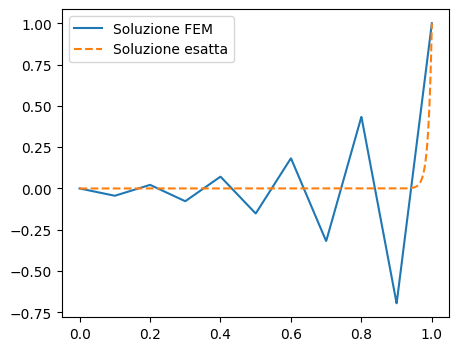

In [14]:
# soluzione esatta
uex = lambda x: (np.exp(x * beta / alpha) - 1) / (np.exp(beta / alpha) - 1)

# soluzione numerica interpolata
interp_uh = lambda x: np.interp(x, grid.nodes, uh)

# x per il plot
xplot = np.linspace(0, 1, 1000)

# rappresentazione grafica
plt.figure(figsize=(5, 4))
plt.plot(xplot, interp_uh(xplot), "-", label="Soluzione FEM")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")
plt.legend()
plt.show()

In [ ]:
# dal plot vediamo che la soluzione numerica non è accurata, questo perché il coefficiente di trasporto domina
#infatti in questo caso beta>>alfa --> è un problema a trasporto dominante
#in questo problema vediamo che la soluzione esatta rimane costante tranne in un piccolo strato limite in cui la soluzione aumenta rapidamente
#se h non è sufficientemente piccolo il metodo numerico non riesce a cogliere questo strato limite, 
# per risolvere questo problema dobbiamo quindi prendere un h molto più piccolo
# Per avere corretta soluzione numerica devo garantire che il numero di Peclet (che descrive i pb di diffusione- trasporto)
# sia minore di 1. Pe=(beta*h)/(2*alfa)
#quindi h<2*alfa/beta ==0.02

<mark>**Esercizio 2.4**</mark></br>

Ripetere l'Esercizio 2.3, variando il valore di $h$, in modo da ottenere una soluzione numerica stabile. 

In [ ]:
#rifare esercizio con h=0.01
#dal grafico vedremo che la soluzione è stabile

# Equazioni di diffusione-trasporto-reazione

Si consideri il seguente problema differenziale, descrivente un fenomeno di diffusione-trasporto-reazione (stazionario)

$$
\begin{cases}
(-\alpha u'+\beta u)'+\gamma u = f, & x\in(0,1)\\
u(0)=u(1)=0.
\end{cases}
$$

dove $\alpha>0,\beta\neq0,\gamma>0$ sono opportuni coefficienti. La corrispondente formulazione debole è
</br></br>
$$\alpha\int_0^1u'v'dx-\beta\int_0^1uv'dx+\gamma\int_0^1uvdx=\int_0^1fvdx.$$

Forma debole
a(u,v) + b(u,v) + c(u,v) =F(v)

Forma algebrica FEM
AU +BU + CU =F 

<mark>**Esercizio 3.1**</mark></br>

Sia $V_h$ lo spazio elementi finiti di grado $r=1$ e passo $h=0.01$. Assemblare le matrici associate alle forme bilineari, senza imporre alcuna condizione al bordo.


In [16]:
from fem_utils import Grid, fun2dof, create_restriction, diffusion, transport, mass

# estremi del dominio
a = 0
b = 1
# dimensione elementi
h = 0.01
# numero elementi
Nele = int((b - a) / h)

# creazione griglia
grid=Grid(a,b,Nele)
grid.compute_geometry()

# assemblaggio matrici di diffusione, trasporto e reazione
A_diff=diffusion(grid)
A_trasp=transport(grid)
A_reac=mass(grid)


<mark>**Esercizio 3.2**</mark></br>

Sfruttando le matrici appena assemblate, risolvere numericamente l'equazione di diffusione-trasporto-reazione per $\alpha=1$, $\beta=2$ e $\gamma=3$. Si ponga $f\equiv-1$. Confrontare la soluzione ottenuta con quella esatta, sapendo l'espressione di quest'ultima è:

$$u(x)=C_1 e^{-x}+C_2e^{3x}-\frac{1}{3},$$

dove $C_2=\frac{1}{3}\frac{e-1}{e^4-1}$ e $C_1=\frac{1}{3}-C_2$.

La matrice di rigidezza totale è definita come $A = A_{\mathrm{diff}} + A_{\mathrm{trasp}} + A_{\mathrm{reaz}}$, includendo i coefficienti di diffusione, reazione e trasporto.

In [17]:
# assemblaggio termine noto
f= lambda x: -1 +0*x
f_dofs=fun2dof(grid,f)
M=A_reac
F=M@f_dofs

# assemblaggio matrice di rigidezza
alpha, beta, gamma = 1, 2, 3
A = alpha*A_diff + beta * A_trasp + gamma * A_reac

# gestione condizioni di Dirichlet
dirichlet_nodes = [0, Nele]
dirichlet_values = [0,1]

bc_values = np.zeros(Nele + 1)
bc_values[dirichlet_nodes] = dirichlet_values
keep_dof = np.ones(Nele + 1, dtype=bool)
keep_dof[dirichlet_nodes] = False

R = create_restriction(keep_dof)
print(R)

A_0 = R @ A @ R.T
rhs_0 = R @(F-A@bc_values)

# risoluzione sistema lineare
u_0 = np.linalg.solve(A_0, rhs_0)
# aggiunta condizione di Dirichlet
u = bc_values + R.T@u_0

[[0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]]


In [18]:
e = np.exp(1)
c2 = (e - 1.0) / (e**4 - 1.0) / 3.0
c1 = 1.0 / 3.0 - c2
uex = lambda x: c1 * np.exp(-x) + c2 * np.exp(3 * x) - 1.0 / 3.0

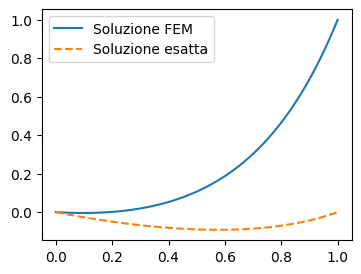

In [19]:
xplot = np.linspace(0, 1, 1000)

plt.figure(figsize=(4, 3))
plt.plot(grid.nodes, u, "-", label="Soluzione FEM")
plt.plot(xplot, uex(xplot), "--", label="Soluzione esatta")
plt.legend()
plt.show()

<mark>**Esercizio 3.3**</mark></br>

Provate a ripetere l'Es. 3.2 per diversi valori di $b \ge 0$. Come cambia la soluzione numerica?

In [ ]:
# tutte le soluzioni numeriche nello stesso grafico al variare di beta
plt.figure(figsize=(6, 4))

for beta in ...
    A = ...

    # risoluzione sistema lineare
    ...

    plt.plot(grid.nodes, u, "-", label=f"$\\beta$ = {beta}")

plt.title("Soluzioni FEM per diversi valori di $\\beta$")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))
plt.grid(True, alpha=0.3)
plt.show()


**Commento**: combinando tutti gli strumenti visti nei Laboratori 10 e 11 è possibile risolvere problemi di diffusione-reazione-trasporto con condizioni di Dirichlet o Neumann. 